In [3]:
!pip install paddlepaddle
!pip install paddleocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 75.5 MB/s  0:00:02m0:00:0100:01

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [10]:
# Importing required methods for inference and visualization.
from paddleocr import PaddleOCR
ocr = PaddleOCR(use_angle_cls=True, enable_mkldnn=False)
# Initializing OCR, OCR will automatically download PP-OCRv3 detector, recognizer and angle classifier.
# ocr = PaddleOCR(use_angle_cls=True)

/tmp/ipykernel_93858/2391594654.py:5: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/teamspace/studios/this_studio/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/teamspace/studios/this_studio/.paddlex/official_models/UVDoc`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/teamspace/studios/this_studio/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/teamspace/studios/this_studio/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None, None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/teamspace/studios/this_studio/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

In [55]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import cv2

def draw_ocr_boxes(image, boxes, txts=None, scores=None, font_path=None):
    # Accept either a PIL Image or a numpy ndarray (BGR as from cv2).
    use_cv2_fallback = False
    orig_img_np = None
    # Debug: log input types to diagnose '_ensure_mutable' issues
    try:
        print('draw_ocr_boxes called. image type:', type(image))
        if isinstance(image, np.ndarray):
            print(' image is ndarray, shape, dtype:', getattr(image, 'shape', None), getattr(image, 'dtype', None))
    except Exception:
        pass
    try:
        print(' boxes type:', type(boxes))
        if isinstance(boxes, (list, tuple)) and len(boxes) > 0:
            print(' sample box type:', type(boxes[0]), 'box len:', len(boxes[0]))
    except Exception:
        pass
    if isinstance(image, np.ndarray):
        orig_img_np = image.copy()
        pil_img = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        # ensure we have a PIL Image
        try:
            pil_img = image.copy()
        except Exception:
            pil_img = Image.fromarray(image)

    # Prepare drawing
    try:
        draw = ImageDraw.Draw(pil_img)
        font = ImageFont.load_default() if font_path is None else ImageFont.truetype(font_path, 16)
        for i, box in enumerate(boxes):
            box_arr = np.array(box).astype(np.int32)
            points = [tuple(int(p) for p in pt) for pt in box_arr]
            draw.polygon(points, outline="red")
            if txts is not None and i < len(txts):
                text = str(txts[i])
                if scores is not None and i < len(scores):
                    try:
                        score = float(scores[i])
                        text += f" {score:.2f}"
                    except Exception:
                        pass
                draw.text(points[0], text, fill="red", font=font)

        result_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        return result_img
    except Exception as e:
        # PIL drawing failed (sometimes due to unexpected image types). Fallback to OpenCV drawing.
        use_cv2_fallback = True

    if use_cv2_fallback:
        if orig_img_np is None:
            # convert pil_img back to numpy BGR
            orig_img_np = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        img = orig_img_np.copy()
        for i, box in enumerate(boxes):
            pts = np.array(box).astype(np.int32).reshape((-1, 2))
            cv2.polylines(img, [pts], isClosed=True, color=(0, 0, 255), thickness=2)
            if txts is not None and i < len(txts):
                text = str(txts[i])
                if scores is not None and i < len(scores):
                    try:
                        score = float(scores[i])
                        text += f" {score:.2f}"
                    except Exception:
                        pass
                # put text at the first point
                org = tuple(int(x) for x in pts[0])
                cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)
        return img

In [56]:
# Function to plot and save the results.
def save_ocr(img_path, out_path, result, font_path=None):
    save_path = os.path.join(out_path, os.path.splitext(os.path.basename(img_path))[0] + '-output.jpg')
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    if not result:
        raise ValueError("Empty OCR result")

    page = result[0] if isinstance(result, list) else result
    boxes = page.get('rec_boxes')
    if boxes is None:
        boxes = page.get('rec_polys')
    if boxes is None:
        boxes = page.get('dt_polys')
    if boxes is None:
        raise ValueError('Could not find boxes in OCR result')
    if isinstance(boxes, np.ndarray):
        print('Resolved boxes as ndarray, converting to list')
        boxes = boxes.tolist()

    print('Result page type:', type(page))
    print('Resolved boxes type:', type(boxes))
    print('Boxes sample:', boxes[:2])

    txts = page.get('rec_texts')
    if txts is None:
        txts = []
    scores = page.get('rec_scores')
    if scores is None:
        scores = []
    if isinstance(txts, np.ndarray):
        txts = txts.tolist()
    if isinstance(scores, np.ndarray):
        scores = scores.tolist()

    im_show = draw_ocr_boxes(image, boxes, txts, scores, font_path=font_path)

    os.makedirs(out_path, exist_ok=True)
    cv2.imwrite(save_path, im_show)

    img = cv2.cvtColor(im_show, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')


In [57]:
# Importing required libraries.
import os
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# Specifying output path and font path.
out_path = '/teamspace/studios/this_studio/output'
# font = './simfang.ttf'

Resolved boxes as ndarray, converting to list
Result page type: <class 'paddlex.inference.pipelines.ocr.result.OCRResult'>
Resolved boxes type: <class 'list'>
Boxes sample: [[332, 26, 437, 58], [212, 36, 276, 59]]
draw_ocr_boxes called. image type: <class 'numpy.ndarray'>
 image is ndarray, shape, dtype: (71, 449, 3) uint8
 boxes type: <class 'list'>
 sample box type: <class 'list'> box len: 4


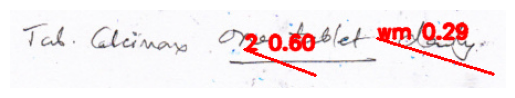

In [60]:


# Add enable_mkldnn=False here to bypass the CPU confli
# Then run your inference
img_path = '/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224133.png'
result = ocr.predict(img_path)
save_ocr(img_path, out_path, result)
 # Use .predict() as suggested by the warning

Resolved boxes as ndarray, converting to list
Result page type: <class 'paddlex.inference.pipelines.ocr.result.OCRResult'>
Resolved boxes type: <class 'list'>
Boxes sample: [[6, 24, 225, 89]]
draw_ocr_boxes called. image type: <class 'numpy.ndarray'>
 image is ndarray, shape, dtype: (89, 266, 3) uint8
 boxes type: <class 'list'>
 sample box type: <class 'list'> box len: 4


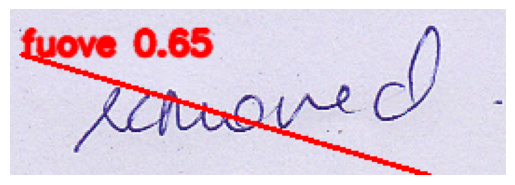

In [61]:


# Add enable_mkldnn=False here to bypass the CPU confli
# Then run your inference
img_path = '/teamspace/studios/this_studio/images/Screenshot 2026-06-02 223503.png'
result = ocr.predict(img_path)
save_ocr(img_path, out_path, result)
 # Use .predict() as suggested by the warning